# Equations of motion

Solve one bubble with three equations of motion, from the incompressible Rayleigh-Plesset equation to the Keller-Miksis equation, which accounts for the compressibility of the liquid. Then raise the drive pressure to see where stable oscillation gives way to inertial cavitation.

All three equations share the same gas, shell, and medium models; they differ in how they treat the liquid around the bubble.

In [ ]:
# Install jbubble on Google Colab, or anywhere it's missing.
import importlib.util

if importlib.util.find_spec("jbubble") is None:
    %pip install --quiet "jbubble[examples]==0.2.0"

In [1]:
import os
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jbubble import SaveSpec, run_simulation
from jbubble.bubble.eom import (
    KellerMiksis,
    ModifiedRayleighPlesset,
    RayleighPlesset,
)
from jbubble.bubble.gas import VanDerWaalsGas
from jbubble.bubble.medium import NewtonianMedium
from jbubble.bubble.shell import NoShell
from jbubble.pulse import HannEnvelope, ToneBurst
from jbubble.pulse.shapes import Sine

plt.style.use("jbubble.style.light")
DRIVE = "#8c959f"  # neutral grey for the acoustic drive in the light theme
QUICK = os.environ.get("JBUBBLE_QUICK") == "1"  # a smaller sweep for CI

## Build three equations of motion

- `RayleighPlesset` treats the liquid as incompressible. It has no way to lose energy to sound, so it overestimates violent growth and collapse.
- `ModifiedRayleighPlesset` adds a first-order correction for the sound that the gas pressure radiates, as in Marmottant et al. (2005).
- `KellerMiksis` keeps the liquid's compressibility to first order in the Mach number of the bubble wall. The presets use it.

The bubble is a 2 µm air bubble in water. A van der Waals gas keeps the collapse physical: the gas can't be compressed below the volume of its molecules, a hard core of radius $R_0 / 8.86$. The liquid is water at 20 °C: `NewtonianMedium` defaults to a density of 998 kg/m³ and the conventional speed of sound of 1500 m/s.

In [2]:
parts = dict(
    gas=VanDerWaalsGas(gamma=1.4, h_frac=1 / 8.86),
    shell=NoShell(sigma=0.072),
    medium=NewtonianMedium(mu=1e-3),  # water: rho_L = 998 kg/m³, c_L = 1500 m/s
    R0=2e-6,
    P_amb=101325.0,
)

models = {
    "Keller-Miksis": KellerMiksis(**parts),
    "Rayleigh-Plesset": RayleighPlesset(**parts),
    "modified Rayleigh-Plesset": ModifiedRayleighPlesset(**parts),
}

## Compare them at 400 kPa

Drive the bubble with three cycles at 1 MHz and 400 kPa under a Hann window. At this pressure the bubble grows to several times its size and then collapses, which is where the equations disagree most. Record 4000 samples, because each collapse lasts only a few nanoseconds.

In [3]:
pulse = ToneBurst(
    freq=1e6, pressure=400e3, shape=Sine(), cycle_num=3, envelope=HannEnvelope()
)
runs = {}
for name, model in models.items():
    start = time.perf_counter()
    runs[name] = run_simulation(
        model, pulse, t_max=6e-6, save_spec=SaveSpec(num_samples=4000)
    )
    elapsed = time.perf_counter() - start
    R = runs[name].radius / model.R0
    print(
        f"{name:26s} R/R0 from {R.min():.3f} to {R.max():.2f}, "
        f"converged: {bool(runs[name].converged)}, {elapsed:.1f} s with compilation"
    )

Keller-Miksis              R/R0 from 0.198 to 2.86, converged: True, 3.6 s with compilation


Rayleigh-Plesset           R/R0 from 0.151 to 4.00, converged: True, 1.6 s with compilation


modified Rayleigh-Plesset  R/R0 from 0.196 to 2.88, converged: True, 1.7 s with compilation


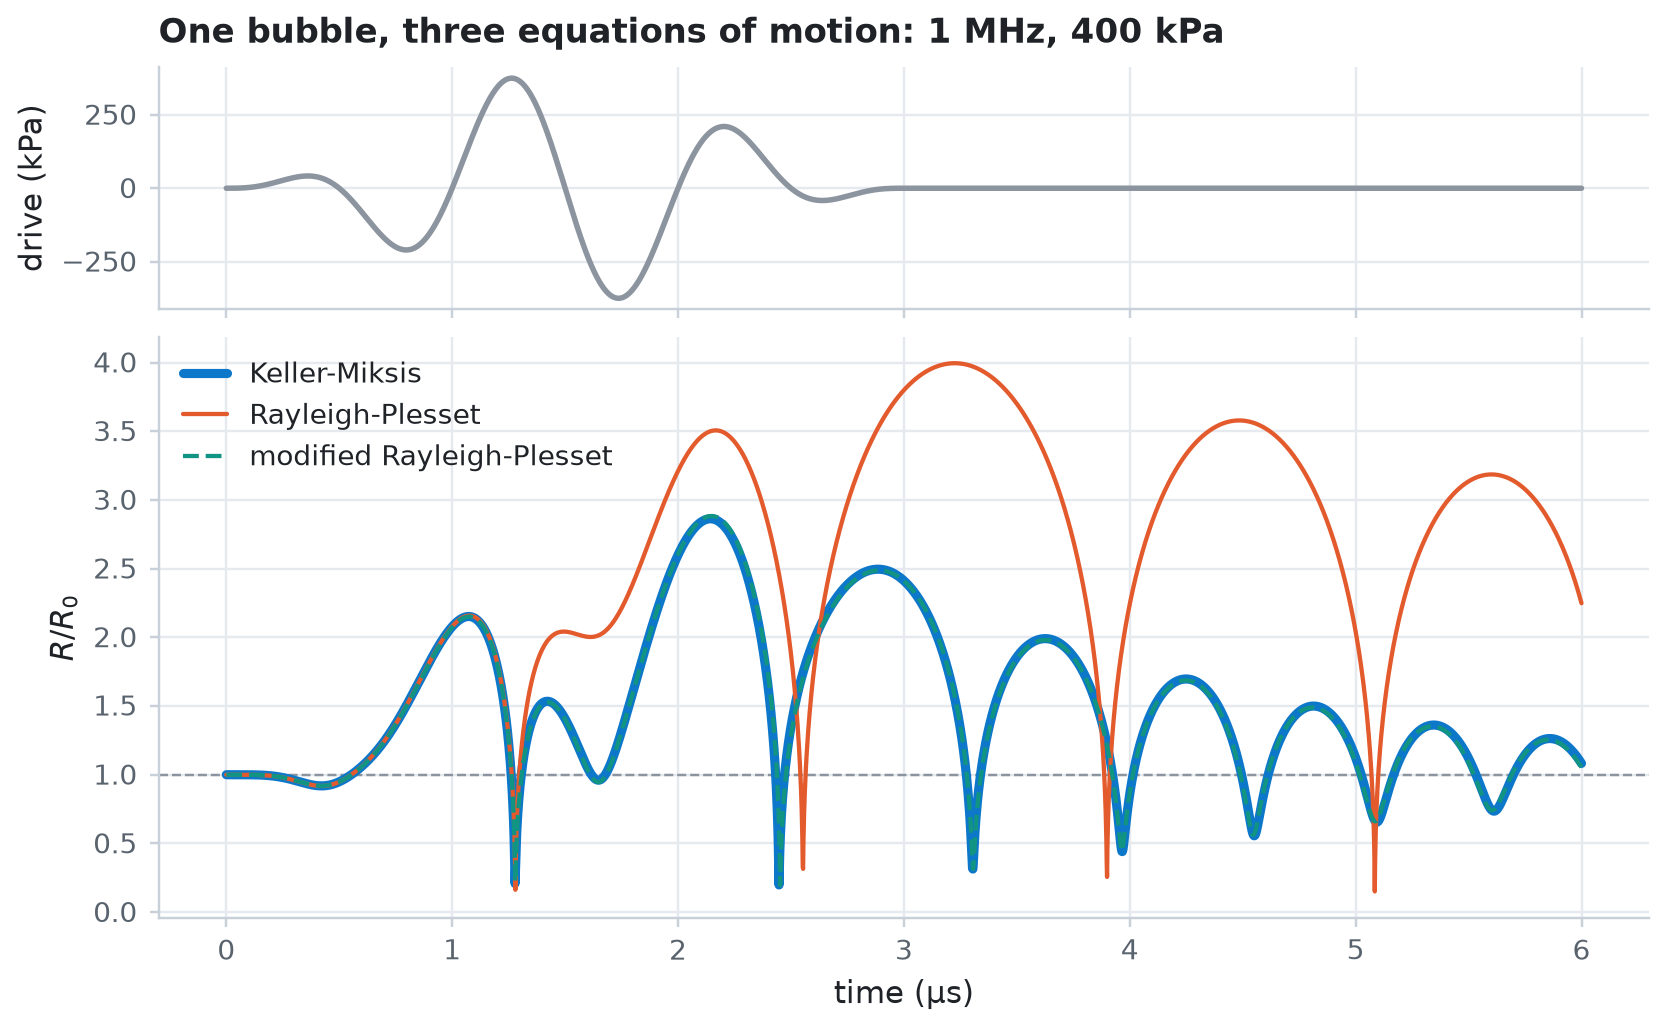

In [4]:
fig, (ax_p, ax_r) = plt.subplots(
    2, 1, figsize=(7.5, 4.6), sharex=True, height_ratios=[1, 2.4]
)
first = runs["Keller-Miksis"]
ax_p.plot(first.ts * 1e6, first.driving_pressure / 1e3, color=DRIVE)
ax_p.set_ylabel("drive (kPa)")
ax_p.set_title("One bubble, three equations of motion: 1 MHz, 400 kPa")
ax_r.axhline(1.0, color=DRIVE, lw=0.8, ls="--")
# Keller-Miksis is wide and underneath; modified Rayleigh-Plesset is dashed on top.
styles = [dict(lw=3.0), dict(lw=1.4), dict(lw=1.4, ls="--")]
for colour, style, (name, run) in zip(
    ["C0", "C1", "C2"], styles, runs.items(), strict=True
):
    ax_r.plot(run.ts * 1e6, run.radius / parts["R0"], color=colour, label=name, **style)
ax_r.set_xlabel("time (µs)")
ax_r.set_ylabel("$R / R_0$")
ax_r.legend(loc="upper left")
plt.show()

Rayleigh-Plesset lets the bubble grow furthest, because an incompressible liquid can't carry energy away as sound. The two equations that radiate sound agree closely at this pressure; they differ mainly in how deep each collapse goes. Keller-Miksis keeps compressibility only to first order in the wall Mach number, so treat its results with care when the wall approaches the speed of sound.

## Find the onset of inertial cavitation

At low pressures the bubble oscillates gently around its equilibrium radius for as long as the drive lasts: stable cavitation. Above a threshold it grows to several times its size and collapses violently under the inertia of the liquid that rushes in: inertial cavitation. A common rule of thumb calls a collapse inertial when the bubble first grows to at least twice its equilibrium radius.

`jax.vmap` runs the Keller-Miksis model at every pressure in one compiled call. A sweep function returns the peak radius together with the solver's `converged` flag, so you can discard any run that failed.

In [5]:
keller_miksis = models["Keller-Miksis"]
pressures = jnp.linspace(10e3, 400e3, 16 if QUICK else 60)


def peak_radius(pressure):
    drive = ToneBurst(
        freq=1e6, pressure=pressure, shape=Sine(), cycle_num=3, envelope=HannEnvelope()
    )
    run = run_simulation(
        keller_miksis, drive, t_max=6e-6, save_spec=SaveSpec(num_samples=2048)
    )
    return run.radius.max() / keller_miksis.R0, run.converged


start = time.perf_counter()
peaks, converged = jax.jit(jax.vmap(peak_radius))(pressures)
peaks.block_until_ready()
print(
    f"{pressures.size} pressures in {time.perf_counter() - start:.1f} s, all converged: {bool(converged.all())}"
)

inertial = peaks >= 2.0
threshold = (
    float(pressures[jnp.argmax(inertial)]) if bool(inertial.any()) else float("nan")
)
print(f"Peak R/R0 first reaches 2 at about {threshold / 1e3:.0f} kPa")

60 pressures in 2.7 s, all converged: True
Peak R/R0 first reaches 2 at about 169 kPa


Plot two runs on either side of the threshold beside the peak radius at every pressure.

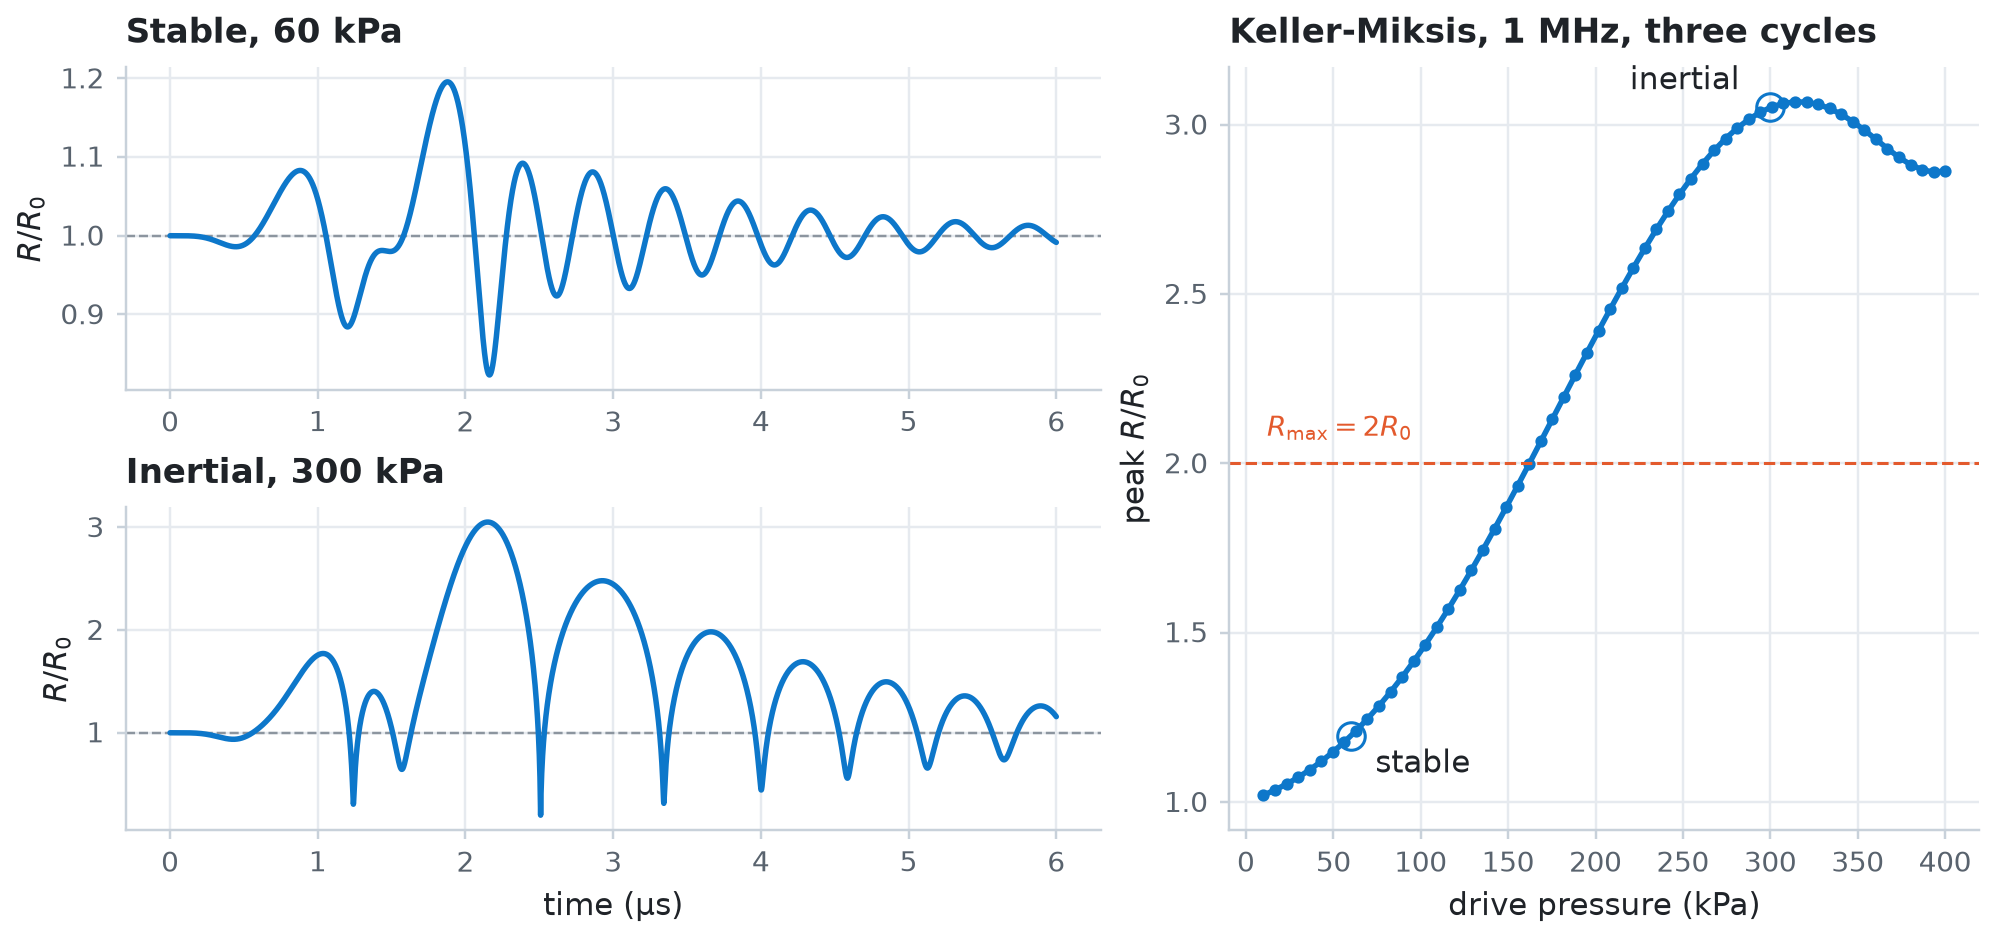

In [6]:
examples = {"stable, 60 kPa": 60e3, "inertial, 300 kPa": 300e3}
fig = plt.figure(figsize=(9.0, 4.2))
grid = fig.add_gridspec(2, 2, width_ratios=[1.3, 1])
ax_peak = fig.add_subplot(grid[:, 1])
for row, (label, pressure) in enumerate(examples.items()):
    drive = ToneBurst(
        freq=1e6, pressure=pressure, shape=Sine(), cycle_num=3, envelope=HannEnvelope()
    )
    run = run_simulation(
        keller_miksis, drive, t_max=6e-6, save_spec=SaveSpec(num_samples=4000)
    )
    ax = fig.add_subplot(grid[row, 0])
    ax.axhline(1.0, color=DRIVE, lw=0.8, ls="--")
    ax.plot(run.ts * 1e6, run.radius / keller_miksis.R0, color="C0")
    ax.set_ylabel("$R / R_0$")
    ax.set_title(label[0].upper() + label[1:])
    peak = float(run.radius.max() / keller_miksis.R0)
    ax_peak.plot(pressure / 1e3, peak, "o", color="C0", mfc="none", ms=9)
    offset, align = ((8, -12), "left") if row == 0 else ((-10, 6), "right")
    ax_peak.annotate(
        label.split(",")[0],
        (pressure / 1e3, peak),
        textcoords="offset points",
        xytext=offset,
        ha=align,
    )
ax.set_xlabel("time (µs)")

ax_peak.plot(pressures / 1e3, peaks, color="C0", marker="o", ms=3)
ax_peak.axhline(2.0, color="C1", lw=1.0, ls="--")
ax_peak.text(12, 2.08, "$R_\\mathrm{max} = 2 R_0$", color="C1", fontsize=9)
ax_peak.set_xlabel("drive pressure (kPa)")
ax_peak.set_ylabel("peak $R / R_0$")
ax_peak.set_title("Keller-Miksis, 1 MHz, three cycles")
plt.show()